# Exploración de modelos alternativos - Proyecto Parte 1

Este notebook es **exploratorio**: no reemplaza a `Proyecto_Parte1_ML_Clasico.ipynb`. La idea es probar otros algoritmos de clasificación de scikit-learn sobre la misma representación del texto y ver si alguno supera a la regresión logística actual.

## Qué se mantiene y qué cambia

| Aspecto | Decisión |
|:---|:---|
| Representación del texto | Se mantiene la del notebook principal: tres bloques de TF-IDF con n-gramas (texto completo, última oración y cláusula final). Es la única técnica de texto usada, así que se respeta la guía. |
| Partición y validación | Igual que en el notebook principal: 20% de prueba estratificado y validación cruzada de 5 particiones con `RANDOM_STATE = 42`. Así las cifras son comparables. |
| Modelos | Cambian. Solo se usan clasificadores de scikit-learn, sin aprendizaje profundo, transformers ni embeddings preentrenados. |
| Archivos | Los modelos y envíos de este notebook llevan otro nombre, para no pisar los del notebook principal. |

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     cross_validate, train_test_split)
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

try:
    stopwords.words('spanish')
except LookupError:
    nltk.download('stopwords')

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
NOMBRE_MODELO = 'exploracion'  # se reemplaza al final por el nombre del mejor modelo

os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Carga y partición de los datos

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
train.head()

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)


,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo p...",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea di...",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficin...",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por...",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. ...",positivo


In [3]:
X = train[['text']]
y = train['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Entrenamiento: (9600, 1) | Prueba: (2400, 1)


## 3. Representación del texto (la misma del notebook principal)

Se copian las funciones de preprocesamiento y de bloques tal como están en el notebook principal (secciones 5 y 8), para que este notebook se pueda ejecutar solo.

In [4]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


# Stop words de NLTK sin tildes, para que coincidan con el texto ya normalizado
stop_nltk = {quitar_tildes(p) for p in stopwords.words('spanish')}

# Palabras de la lista de NLTK que expresan negación, contraste o intensidad
negaciones = {'no', 'ni', 'nada', 'nunca', 'ningun', 'sin', 'pero', 'muy', 'mas', 'poco',
              'mucho', 'tanto', 'si', 'aunque'}
stop_sin_negaciones = stop_nltk - negaciones


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)

In [5]:
def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

## 4. Funciones para comparar modelos

In [6]:
def metricas(y_real, y_pred):
    return {'Exactitud': accuracy_score(y_real, y_pred),
            'Precisión (macro)': precision_score(y_real, y_pred, average='macro'),
            'Recall (macro)': recall_score(y_real, y_pred, average='macro'),
            'F1 (macro)': f1_score(y_real, y_pred, average='macro')}


resultados = {}


def buscar_hiperparametros(nombre, modelo, grilla):
    pipe = Pipeline([('rep', construir_representacion()), ('modelo', modelo)])
    busqueda = GridSearchCV(pipe, grilla, cv=kfold, scoring='f1_macro', n_jobs=-1)
    busqueda.fit(X_train, y_train)

    y_pred = busqueda.predict(X_test)
    resultados[nombre] = {'busqueda': busqueda, 'y_pred': y_pred,
                          'cv_f1': busqueda.best_score_, **metricas(y_test, y_pred)}

    print('Mejores hiperparámetros:', busqueda.best_params_)
    print(f'F1-macro en validación cruzada: {busqueda.best_score_:.4f}')
    print(f'Prueba -> exactitud: {resultados[nombre]["Exactitud"]:.4f} | F1-macro: {resultados[nombre]["F1 (macro)"]:.4f}')


def resumen_busqueda(nombre, n=5):
    r = pd.DataFrame(resultados[nombre]['busqueda'].cv_results_)
    columnas = [c for c in r.columns if c.startswith('param_')] + ['mean_test_score', 'std_test_score', 'rank_test_score']
    return r[columnas].sort_values('rank_test_score').head(n).round(4)

## 5. Modelos

### 5.1 Regresión logística (referencia)

Es el modelo del notebook principal. Se incluye con la misma grilla para tener una referencia dentro de este notebook.

In [7]:
grilla_lr = [
    {'modelo__penalty': ['l1'], 'modelo__solver': ['liblinear'], 'modelo__C': [3, 10, 30]},
    {'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear'], 'modelo__C': [3, 10, 30]},
]

buscar_hiperparametros('Regresión logística', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), grilla_lr)
resumen_busqueda('Regresión logística')

Mejores hiperparámetros: {'modelo__C': 10, 'modelo__penalty': 'l1', 'modelo__solver': 'liblinear'}
F1-macro en validación cruzada: 0.8992
Prueba -> exactitud: 0.8946 | F1-macro: 0.8993


,param_modelo__C,param_modelo__penalty,param_modelo__solver,mean_test_score,std_test_score,rank_test_score
1,10,l1,liblinear,0.8992,0.0072,1
0,3,l1,liblinear,0.8984,0.0078,2
2,30,l1,liblinear,0.8962,0.0076,3
5,30,l2,liblinear,0.8944,0.0106,4
4,10,l2,liblinear,0.8942,0.0118,5


### 5.2 SVM lineal (`LinearSVC`)

Busca el hiperplano que separa las clases con el mayor margen. Con matrices dispersas de miles de columnas suele ser tan bueno como la regresión logística y más rápido. Se busca el parámetro `C` (a mayor `C`, menos regularización).

In [8]:
grilla_svm = {'modelo__C': [0.05, 0.1, 0.3, 1, 3], 'modelo__class_weight': [None, 'balanced']}

buscar_hiperparametros('SVM lineal', LinearSVC(random_state=RANDOM_STATE), grilla_svm)
resumen_busqueda('SVM lineal')

Mejores hiperparámetros: {'modelo__C': 0.3, 'modelo__class_weight': None}
F1-macro en validación cruzada: 0.8957
Prueba -> exactitud: 0.8954 | F1-macro: 0.8990


,param_modelo__C,param_modelo__class_weight,mean_test_score,std_test_score,rank_test_score
4,0.3,None,0.8957,0.0100,1
5,0.3,balanced,0.8954,0.0103,2
7,1.0,balanced,0.8946,0.0105,3
6,1.0,None,0.8945,0.0106,4
9,3.0,balanced,0.8919,0.0103,5


### 5.3 Gradiente descendente estocástico (`SGDClassifier`)

Entrena un modelo lineal actualizando los pesos con un ejemplo a la vez. Según la función de pérdida es una SVM (`hinge`), una regresión logística (`log_loss`) o algo intermedio (`modified_huber`). Se busca la pérdida, la regularización (`alpha`) y el tipo de penalización.

In [9]:
grilla_sgd = {
    'modelo__loss': ['hinge', 'modified_huber', 'log_loss'],
    'modelo__alpha': [1e-5, 3e-5, 1e-4, 3e-4],
    'modelo__penalty': ['l2', 'elasticnet'],
}

buscar_hiperparametros('SGD', SGDClassifier(max_iter=100, tol=1e-4, random_state=RANDOM_STATE), grilla_sgd)
resumen_busqueda('SGD')

/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Mejores hiperparámetros: {'modelo__alpha': 0.0001, 'modelo__loss': 'hinge', 'modelo__penalty': 'elasticnet'}
F1-macro en validación cruzada: 0.8973
Prueba -> exactitud: 0.8979 | F1-macro: 0.9018


,param_modelo__alpha,param_modelo__loss,param_modelo__penalty,mean_test_score,std_test_score,rank_test_score
13,0.0001,hinge,elasticnet,0.8973,0.0087,1
15,0.0001,modified_huber,elasticnet,0.8969,0.0106,2
21,0.0003,modified_huber,elasticnet,0.8966,0.0104,3
20,0.0003,modified_huber,l2,0.8962,0.0113,4
18,0.0003,hinge,l2,0.8960,0.0073,5


### 5.4 Clasificador de Ridge (`RidgeClassifier`)

Es una regresión lineal con regularización L2 aplicada a las etiquetas codificadas, y la clase se elige con el mayor valor. Se busca `alpha` (a mayor `alpha`, más regularización).

In [10]:
grilla_ridge = {'modelo__alpha': [0.3, 1, 3, 10], 'modelo__class_weight': [None, 'balanced']}

buscar_hiperparametros('Ridge', RidgeClassifier(random_state=RANDOM_STATE), grilla_ridge)
resumen_busqueda('Ridge')

Mejores hiperparámetros: {'modelo__alpha': 1, 'modelo__class_weight': 'balanced'}
F1-macro en validación cruzada: 0.8936
Prueba -> exactitud: 0.8929 | F1-macro: 0.8965


,param_modelo__alpha,param_modelo__class_weight,mean_test_score,std_test_score,rank_test_score
3,1.0,balanced,0.8936,0.0099,1
2,1.0,None,0.8932,0.0101,2
1,0.3,balanced,0.8916,0.0095,3
0,0.3,None,0.8911,0.0098,4
4,3.0,None,0.8908,0.0097,5


### 5.5 Naive Bayes complementario (`ComplementNB`)

Variante de Naive Bayes que estima los parámetros de cada clase con los ejemplos de **todas las demás**. Se diseñó para texto y para clases desbalanceadas. Se compara con el `MultinomialNB` del notebook principal.

In [11]:
grilla_nb = {'modelo__alpha': [0.1, 0.3, 0.5, 1]}

buscar_hiperparametros('Naive Bayes complementario', ComplementNB(), grilla_nb)
resumen_busqueda('Naive Bayes complementario')

buscar_hiperparametros('Naive Bayes multinomial', MultinomialNB(), grilla_nb)
resumen_busqueda('Naive Bayes multinomial')

Mejores hiperparámetros: {'modelo__alpha': 0.1}
F1-macro en validación cruzada: 0.8698
Prueba -> exactitud: 0.8783 | F1-macro: 0.8802


Mejores hiperparámetros: {'modelo__alpha': 0.5}
F1-macro en validación cruzada: 0.8859
Prueba -> exactitud: 0.8862 | F1-macro: 0.8897


,param_modelo__alpha,mean_test_score,std_test_score,rank_test_score
2,0.5,0.8859,0.0085,1
1,0.3,0.8858,0.0093,2
0,0.1,0.8854,0.0092,3
3,1.0,0.8836,0.0095,4


### 5.6 Ensambles: votación y apilamiento

Dos formas de combinar modelos distintos, ambas de scikit-learn:

- **Votación suave (`VotingClassifier`):** promedia las probabilidades de la regresión logística, Naive Bayes multinomial y SGD (`modified_huber`).
- **Apilamiento (`StackingClassifier`):** entrena una regresión logística final que usa como entrada las predicciones (por validación cruzada) de la regresión logística, Naive Bayes multinomial y la SVM lineal.

Los hiperparámetros de los modelos base son los mejores encontrados arriba, así que aquí no se busca nada nuevo.

In [12]:
p_lr = resultados['Regresión logística']['busqueda'].best_params_
p_svm = resultados['SVM lineal']['busqueda'].best_params_
p_sgd = resultados['SGD']['busqueda'].best_params_
p_nb = resultados['Naive Bayes multinomial']['busqueda'].best_params_


def quitar_prefijo(parametros):
    return {k.replace('modelo__', ''): v for k, v in parametros.items()}


lr = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, **quitar_prefijo(p_lr))
nb = MultinomialNB(**quitar_prefijo(p_nb))
svm = LinearSVC(random_state=RANDOM_STATE, **quitar_prefijo(p_svm))
sgd = SGDClassifier(max_iter=100, tol=1e-4, random_state=RANDOM_STATE, **{**quitar_prefijo(p_sgd), 'loss': 'modified_huber'})

votacion = VotingClassifier([('lr', lr), ('nb', nb), ('sgd', sgd)], voting='soft')
apilado = StackingClassifier([('lr', lr), ('nb', nb), ('svm', svm)],
                             final_estimator=LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), cv=5)

for nombre, modelo in [('Votación suave', votacion), ('Apilamiento', apilado)]:
    pipe = Pipeline([('rep', construir_representacion()), ('modelo', modelo)])
    f1_cv = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='f1_macro', n_jobs=-1).mean()
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    resultados[nombre] = {'busqueda': type('Busqueda', (), {'best_estimator_': pipe})(), 'y_pred': y_pred,
                          'cv_f1': f1_cv, **metricas(y_test, y_pred)}
    print(f'{nombre}: F1-macro CV = {f1_cv:.4f} | prueba -> exactitud {resultados[nombre]["Exactitud"]:.4f}, F1-macro {resultados[nombre]["F1 (macro)"]:.4f}')

Votación suave: F1-macro CV = 0.8991 | prueba -> exactitud 0.8929, F1-macro 0.8968


Apilamiento: F1-macro CV = 0.9014 | prueba -> exactitud 0.9000, F1-macro 0.9047


## 6. Comparación de modelos

,F1-macro (CV),Exactitud (test),Precisión macro (test),Recall macro (test),F1-macro (test)
Apilamiento,0.9014,0.9000,0.9045,0.9049,0.9047
Regresión logística,0.8992,0.8946,0.8987,0.8998,0.8993
Votación suave,0.8991,0.8929,0.8958,0.8982,0.8968
SGD,0.8973,0.8979,0.9010,0.9029,0.9018
SVM lineal,0.8957,0.8954,0.8977,0.9005,0.8990
Ridge,0.8936,0.8929,0.8952,0.8982,0.8965
Naive Bayes multinomial,0.8859,0.8862,0.8887,0.8916,0.8897
Naive Bayes complementario,0.8698,0.8783,0.8791,0.8843,0.8802


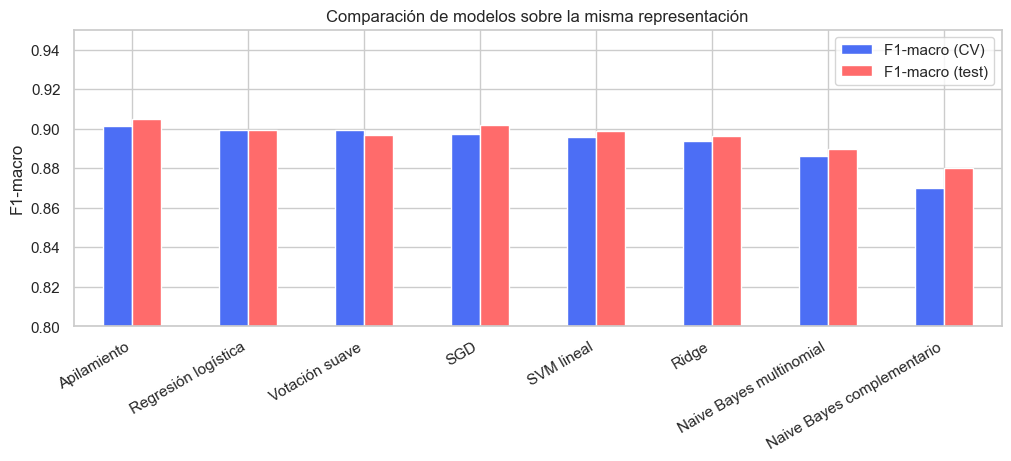

In [13]:
tabla_modelos = pd.DataFrame(
    {n: {'F1-macro (CV)': r['cv_f1'], 'Exactitud (test)': r['Exactitud'],
         'Precisión macro (test)': r['Precisión (macro)'], 'Recall macro (test)': r['Recall (macro)'],
         'F1-macro (test)': r['F1 (macro)']} for n, r in resultados.items()}
).T.sort_values('F1-macro (CV)', ascending=False)

display(tabla_modelos.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
tabla_modelos[['F1-macro (CV)', 'F1-macro (test)']].plot(kind='bar', ax=ax, color=['#4C6EF5', '#FF6B6B'])
ax.set(ylabel='F1-macro', title='Comparación de modelos sobre la misma representación', ylim=(0.8, 0.95))
plt.xticks(rotation=30, ha='right')
plt.show()

## 7. Modelo final y predicciones

In [14]:
mejor_nombre = tabla_modelos['F1-macro (CV)'].idxmax()
mejor_modelo = resultados[mejor_nombre]['busqueda'].best_estimator_
print('Mejor modelo según F1-macro en validación cruzada:', mejor_nombre)

NOMBRE_MODELO = 'exploracion_' + unicodedata.normalize('NFKD', mejor_nombre.lower()).encode('ascii', 'ignore').decode().replace(' ', '_')
print('Archivos:', NOMBRE_MODELO)

cv_acc = cross_val_score(clone(mejor_modelo), X, y, cv=kfold, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(clone(mejor_modelo), X, y, cv=kfold, scoring='f1_macro', n_jobs=-1)
print(f'Exactitud en validación cruzada (12.000 reseñas): {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'F1-macro en validación cruzada (12.000 reseñas):  {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')

Mejor modelo según F1-macro en validación cruzada: Apilamiento
Archivos: exploracion_apilamiento


Exactitud en validación cruzada (12.000 reseñas): 0.8992 +/- 0.0035
F1-macro en validación cruzada (12.000 reseñas):  0.9036 +/- 0.0034


In [15]:
modelo_final = clone(mejor_modelo)
modelo_final.fit(X, y)

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)

joblib.dump(modelo_final, os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib'))

print('Mismas columnas que sample_submission:', list(envio.columns) == list(muestra_envio.columns))
print('Mismos ids y en el mismo orden:', (envio['id'] == muestra_envio['id']).all())
print('Valores nulos:', envio['answer'].isna().sum())
pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
              'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3)

Mismas columnas que sample_submission: True
Mismos ids y en el mismo orden: True
Valores nulos: 0


,train (real),eval (predicho)
negativo,0.351,0.356
neutral,0.298,0.279
positivo,0.351,0.365


## 8. Conclusiones

- Los modelos lineales quedan todos muy juntos: regresión logística (F1-macro en validación cruzada de 0,8992), SGD (0,8973), SVM lineal (0,8957) y Ridge (0,8936). Entre ellos hay menos de 0,006 de diferencia, menos que la desviación entre particiones (cerca de 0,010), así que no se puede decir que uno sea mejor que otro.
- Naive Bayes complementario (0,8698) queda por debajo del multinomial (0,8859), a pesar de estar pensado para texto. Ninguno de los dos supera a los modelos lineales.
- Los ensambles son los únicos que se despegan un poco. El apilamiento de regresión logística, Naive Bayes y SVM lineal llega a 0,9014 en validación cruzada y 0,9047 en prueba, frente a 0,8992 y 0,8993 de la regresión logística sola. La votación suave no mejora (0,8991).
- La ganancia del apilamiento es de unos 0,002 a 0,005 de F1-macro. Es pequeña frente a la desviación entre particiones, así que no es una mejora segura. Además cuesta más: entrena tres modelos y un cuarto encima.
- Todos los modelos comparten la misma representación y el mismo techo. Como se vio en el notebook principal, cerca del 12% de las reseñas positivas o negativas terminan en una frase de cierre ambigua y en ellas ningún modelo supera el azar. Cambiar de algoritmo no resuelve eso; la ganancia que falta está en los datos y no en el modelo.
- Los archivos de este notebook (`exploracion_apilamiento.joblib` y `submission_exploracion_apilamiento.csv`) no reemplazan a los del notebook principal. Si se quiere probar en Kaggle, el modelo apilado es el candidato; si no mejora el puntaje del grupo, se mantiene la regresión logística.